In [1]:
# Setup
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# GPU memory config
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

print(f"TensorFlow version: {tf.__version__}")
print("GPU Available:", tf.config.list_physical_devices('GPU'))

np.random.seed(42)
tf.random.set_seed(42)

2026-03-09 15:55:33.448154: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-09 15:55:33.839458: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-09 15:55:36.021715: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Build Autoencoder
def build_autoencoder():
    inputs = keras.Input(shape=(32, 32, 1))     # 1 Channel as MSINT only has grayscale images

    # Encoder
    x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)      # Batch normalization on MNIST is optional as the dataset is relatively simple, but it can help with training stability and convergence
    x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # Bottleneck
    encoded = layers.Conv2D(16, 1, activation='relu', name='bottleneck')(x)

    # Decoder
    x = layers.Conv2D(64, 1, activation='relu')(encoded)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2DTranspose(16, 3, strides=2, padding='same', activation='relu')(x)

    outputs = layers.Conv2D(1, 3, padding='same', activation='sigmoid')(x)      # Sigmoid activation for pixel values in [0, 1], works well for grayscale images especially when using binary crossentropy loss

    return keras.Model(inputs, outputs)

model = build_autoencoder()
model.summary()

I0000 00:00:1773071737.722361   16918 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 16, 16, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Conv2D)             │ (None, 8, 8, 16)       │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 16)     │         4,624 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,945 (175.57 KB)

 Trainable params: 44,561 (174.07 KB)

 Non-trainable params: 384 (1.50 KB)

In [3]:
# Load MNIST
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalise to [0, 1] for sigmoid/binary crossentropy compatibility
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# MNIST images are 28x28 so pad to 32x32
x_train = np.pad(x_train, ((0,0), (2,2), (2,2)), mode='constant')
x_test  = np.pad(x_test,  ((0,0), (2,2), (2,2)), mode='constant')

# Add channel dimension, no need to convert to RGB and repeat for 3 channels as MNIST only has grayscale images
x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test,  -1)

print(f"Training data: {x_train.shape}")
print(f"Test data:     {x_test.shape}")

# Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',     # Binary crossentropy works well for pixel values in [0, 1], especially with sigmoid activation in the output layer
    metrics=['mse']
)

# Train
history = model.fit(
    x_train, x_train,
    batch_size=128,
    epochs=10,
    validation_data=(x_test, x_test),
    verbose=1
)

Training data: (60000, 32, 32, 1)
Test data:     (10000, 32, 32, 1)
Epoch 1/10


2026-03-09 15:55:42.781783: I external/local_xla/xla/service/service.cc:163] XLA service 0x779794017160 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-09 15:55:42.782060: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-03-09 15:55:42.900397: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-09 15:55:43.487290: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


 31/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5758 - mse: 0.1813

I0000 00:00:1773071747.736641   17012 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 0.0816 - mse: 0.0099 - val_loss: 0.0690 - val_mse: 0.0071
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0481 - mse: 7.0013e-04 - val_loss: 0.0473 - val_mse: 5.5180e-04
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0474 - mse: 5.3426e-04 - val_loss: 0.0468 - val_mse: 4.4874e-04
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0470 - mse: 4.4566e-04 - val_loss: 0.0465 - val_mse: 3.9619e-04
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0467 - mse: 3.8804e-04 - val_loss: 0.0464 - val_mse: 3.6694e-04
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0465 - mse: 3.4986e-04 - val_loss: 0.0462 - val_mse: 3.3035e-04
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0464 - mse: 3.2022e-04 - val_loss: 0.0461 - val_mse: 2.9582e-04
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0463 - mse: 2.9706e-04 - val_loss: 0.0460 - val_mse: 2.8409e-04
Epoch 9/1

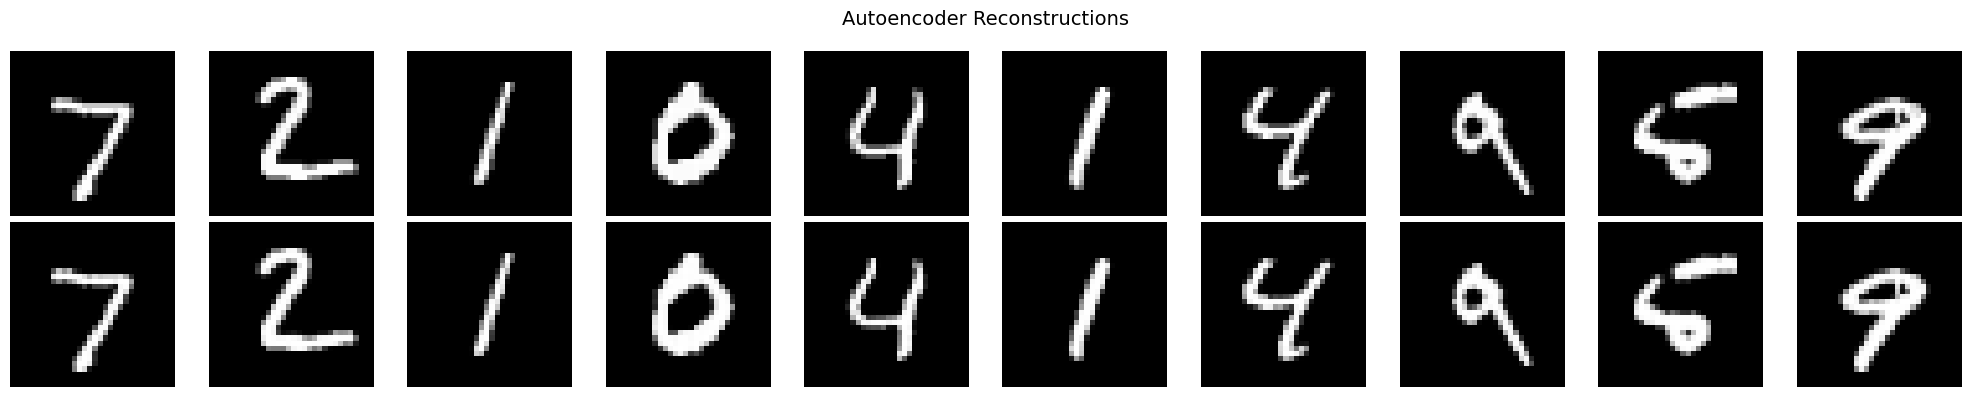

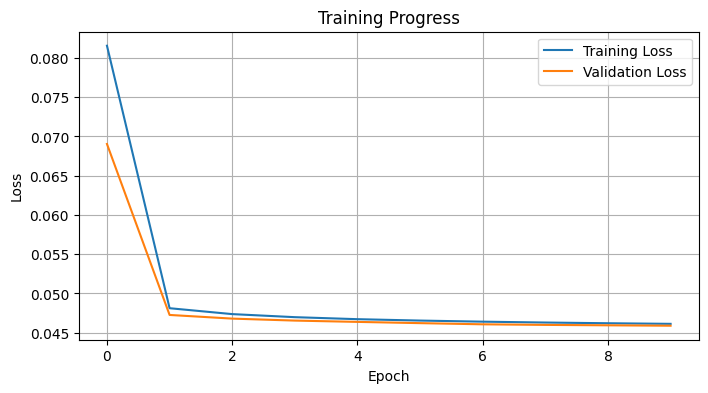

Final training loss:   0.0461
Final validation loss: 0.0459


In [ ]:
# Reconstruct 10 test images
test_samples  = x_test[:10]
reconstructed = model.predict(test_samples, verbose=0)

# Show originals vs reconstructions
fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
    axes[0, i].imshow(test_samples[i], cmap='gray')         # cmap='gray' for grayscale images, otherwise matplotlib will use viridis colourmap as default and output purple/green images
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Original', fontsize=12)

    axes[1, i].imshow(np.clip(reconstructed[i], 0, 1), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('Reconstructed', fontsize=12)

plt.suptitle('Autoencoder Reconstructions', fontsize=14)
plt.tight_layout()
plt.show()

# Training loss curve
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Progress')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final training loss:   {history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")